In [72]:
import math, random
import matplotlib.pyplot as plt

In [ ]:
class Example_NN:
    def __init__(self, 
                 depth = 3, 
                 width = 3, 
                 lr = 0.1, 
                 n_iter = 1000, 
                 input_dim = 5,
                 output_dim = 1, 
                 layer_dim = 3):
        
        self.depth = depth
        self.width = width 
        self.layer_dim = layer_dim
        self.output_dim = output_dim
        self.lr = lr
        self.n_iter = n_iter

        self.weight = [[[random.uniform(-1, 1) for _ in range(layer_dim)] for _ in range(input_dim)],
                       *[[[random.uniform(-1, 1) for _ in range(layer_dim)] for _ in range(layer_dim)] for _ in range(depth-2)],
                       [[random.uniform(-1, 1) for _ in range(output_dim)] for _ in range(layer_dim)]]
        self.bias = [*[[random.uniform(-1, 1) for _ in range(layer_dim)] for _ in range(depth-1)],
                     [random.uniform(-1, 1) for _ in range(output_dim)]]

    def sigmoid(self, x):
        return 1 / (1 + math.exp(-x))
    
    def forward(self, vec):
        self.activations = []
        activation = vec
        self.activations.append(activation)

        for i in range(len(self.weight)):
            activation_new = []
            for j in range(len(self.bias[i])):
                sum = 0
                for m in range(len(self.weight[i][0])):
                    sum += self.weight[i][m][j] * activation[m]
                activation_new.append(self.sigmoid(sum + self.bias[i][j]))
            
            activation = activation_new
            self.activations.append(activation)
    
    def loss_function(self, x, y):
        sum = 0
        for i in range(len(x)):
            sum += (x[i] - y[i])**2
        return sum / len(x)
    
    def backprop(self, target):

        delta = [(self.activations[-1][j] - target[j]) * self.activations[-1][j] * (1 - self.activations[-1][j]) 
                    for j in range(self.output_dim)]
            
        prev_a = self.activations[-2]
        for j in range(self.output_dim):
            for m in range(len(prev_a)):
                self.weight[-1][m][j] -= self.lr * delta[j] * prev_a[m]
            self.bias[-1][j] -= self.lr * delta[j]

        for i in range(1, self.depth):
            idx = -(i + 1)
            delta_new = []
            prev_a = self.activations[idx]

            for j in range(len(self.bias[idx])):
                sum = 0
                for m in range(len(delta)):
                    sum += self.weight[idx][m][j] * delta[m]
                d_sigma = self.activations[idx][j] * (1 - self.activations[idx][j])
                delta_new.append(sum * d_sigma)
                    
            for j in range(len(self.bias[idx])):
                for m in range(len(prev_a)):
                    self.weight[idx][m][j] -= self.lr * delta_new[j] * prev_a[m]
                self.bias[idx][j] -= self.lr * delta_new[j]
        
            delta = delta_new

    def train(self, input, target):
        loss_arr = []
        for epoch in range(self.n_iter):
            self.forward(input)
            self.backprop(target)

            loss = self.loss_function(target, self.activations[-1])
            loss_arr.append(loss)
            out = self.activations[-1]

            if epoch % 200 == 0:
                print('=' * 10)
                print('Epoch:', epoch)
                print('Loss:', loss)
                print('Out:', out)
        return loss_arr

In [81]:
nn = Example_NN()
input = [random.uniform(-10, 10) for _ in range(7)]
target = [0.7823]
training = nn.train(input, target)

Epoch: 0
Loss: 0.05426075844858454
Out: [0.5493606120713276]
Epoch: 200
Loss: 0.004405642366988708
Out: [0.7159249868776758]
Epoch: 400
Loss: 0.0006657236984090843
Out: [0.7564983779887953]
Epoch: 600
Loss: 0.00012600217855558834
Out: [0.7710749307995189]
Epoch: 800
Loss: 2.60965936842767e-05
Out: [0.7771915174773445]


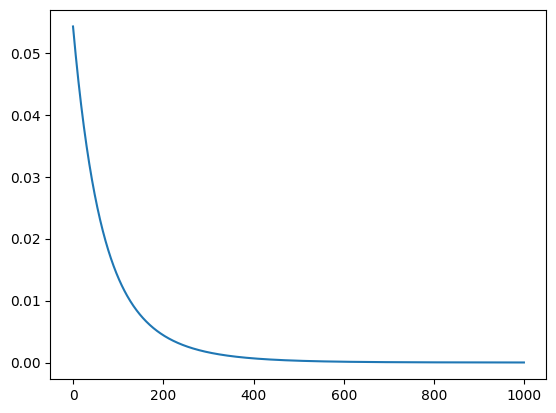

In [82]:
plt.plot([i for i in range(len(training))], training)